##Premium Quote Prediction - Bike

##Workflow

1. Import libraries
2. Load dataset
3. Data inspection (head, info, describe)
4. Duplicate analysis
5. Missing value analysis
6. Exploratory Data Analysis (visualizations)
7. Train/test split
8. Build preprocessing + model pipeline
9. Train the model
10. Evaluation (MAE, RMSE, R²)
11. Save the trained pipeline

##Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

##Load Dataset

In [ ]:
df_bike = pd.read_csv('/content/acko_bike_quotation.csv')



##Data inspection

In [ ]:
df_bike.shape


#(150000, 28)

(150000, 28)

In [ ]:
df_bike.head()

,record_id,customer_age,city,state,city_tier,city_risk_score,vehicle_make,vehicle_model,variant,segment,...,policy_type,usage_type,num_addons,addons_list,od_premium_before_ncb,ncb_discount_amount,tp_premium,addon_premium,gst_amount,annual_premium
0,c007100c,60,Rajahmundry,Andhra Pradesh,3,0.88,Royal Enfield,Bullet 500,STD,retro,...,Comprehensive,Personal,0,NaN,3861.87,0.00,2804,0.00,1295.85,8338
1,01557b26,21,Indore,Madhya Pradesh,2,1.15,Yamaha,Fascino 125,ABS,scooter,...,Third Party,Personal,0,NaN,1139.68,512.86,714,0.00,151.65,1035
2,656c8f49,19,Patna,Bihar,2,1.20,Suzuki,Gixxer 150,Drum,sport,...,Third Party,Personal,3,"Roadside Assistance, Consumables Cover, Return...",2464.40,862.54,1366,3317.48,290.14,1829
3,506ccfca,20,Muzaffarpur,Bihar,3,0.88,Bounce,Infinity E1,ABS,ev_scooter,...,Comprehensive,Personal,0,NaN,702.02,315.91,687,0.00,227.93,1536
4,3d46cd32,19,Karnal,Haryana,3,0.90,Honda,CB Hornet 2.0,Limited Edition,sport,...,Own Damage,Personal,0,NaN,2164.95,974.23,1366,0.00,252.91,1731


In [ ]:
df_bike.columns

Index(['record_id', 'customer_age', 'city', 'state', 'city_tier',
       'city_risk_score', 'vehicle_make', 'vehicle_model', 'variant',
       'segment', 'fuel_type', 'colour', 'manufacturing_year',
       'vehicle_age_years', 'engine_cc', 'idv', 'ncb_percent',
       'claim_history_count', 'policy_type', 'usage_type', 'num_addons',
       'addons_list', 'od_premium_before_ncb', 'ncb_discount_amount',
       'tp_premium', 'addon_premium', 'gst_amount', 'annual_premium'],
      dtype='object')

In [ ]:
df_bike.describe()

,customer_age,city_tier,city_risk_score,manufacturing_year,vehicle_age_years,engine_cc,idv,ncb_percent,claim_history_count,num_addons,od_premium_before_ncb,ncb_discount_amount,tp_premium,addon_premium,gst_amount,annual_premium
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,41.495560,2.434287,1.031477,2014.499307,10.500693,215.089827,1.092865e+05,29.160267,0.671833,0.919227,5735.309428,1676.895140,1296.850427,687.122142,861.266757,5646.404507
std,13.849514,0.620251,0.160689,5.775248,5.775248,269.929363,1.832771e+05,16.671414,0.874306,0.924389,9828.518608,3453.377221,811.710032,768.923055,1331.826527,8736.957401
min,18.000000,1.000000,0.820000,2005.000000,1.000000,0.000000,1.500000e+04,0.000000,0.000000,0.000000,469.450000,0.000000,687.000000,0.000000,56.120000,538.000000
25%,30.000000,2.000000,0.900000,2009.000000,5.000000,0.000000,3.437800e+04,20.000000,0.000000,0.000000,1431.057500,303.592500,687.000000,0.000000,245.880000,1666.000000
50%,41.000000,3.000000,1.000000,2014.000000,11.000000,125.000000,5.633900e+04,25.000000,0.000000,1.000000,2469.465000,666.270000,714.000000,553.915000,504.720000,3263.000000
75%,54.000000,3.000000,1.120000,2020.000000,16.000000,312.000000,1.035392e+05,45.000000,1.000000,2.000000,5332.227500,1527.340000,1366.000000,1065.695000,870.900000,5711.000000
max,65.000000,3.000000,1.500000,2024.000000,20.000000,1833.000000,3.801389e+06,50.000000,3.000000,3.000000,260756.420000,91337.740000,2804.000000,3599.660000,37645.010000,252983.000000


In [ ]:
df_bike.describe(include='object')

,record_id,city,state,vehicle_make,vehicle_model,variant,segment,fuel_type,colour,policy_type,usage_type,addons_list
count,150000,150000,150000,150000,150000,150000,150000,150000,150000,150000,150000,89827
unique,149999,117,32,13,138,16,16,2,12,3,3,156
top,a09ddc4e,Karnal,Maharashtra,Suzuki,Infinity E1,Pro,ev_scooter,Petrol,Candy Orange,Comprehensive,Personal,Consumables Cover
freq,2,1381,19415,11657,11647,9521,48110,101890,12673,90175,120039,8844


In [ ]:
df_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 28 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   record_id              150000 non-null  object 
 1   customer_age           150000 non-null  int64  
 2   city                   150000 non-null  object 
 3   state                  150000 non-null  object 
 4   city_tier              150000 non-null  int64  
 5   city_risk_score        150000 non-null  float64
 6   vehicle_make           150000 non-null  object 
 7   vehicle_model          150000 non-null  object 
 8   variant                150000 non-null  object 
 9   segment                150000 non-null  object 
 10  fuel_type              150000 non-null  object 
 11  colour                 150000 non-null  object 
 12  manufacturing_year     150000 non-null  int64  
 13  vehicle_age_years      150000 non-null  int64  
 14  engine_cc              150000 non-nu

##Duplicate Analysis

In [ ]:
df_bike.duplicated().sum()

np.int64(0)

In [ ]:
df_bike.drop(columns=['record_id']).duplicated().sum()

np.int64(0)

##Missing Value Analysis

In [ ]:
df_bike.isna().sum()

,0
record_id,0
customer_age,0
city,0
state,0
city_tier,0
city_risk_score,0
vehicle_make,0
vehicle_model,0
variant,0
segment,0


In [ ]:
df_bike['addons_list'].head()

,addons_list
0,NaN
1,NaN
2,"Roadside Assistance, Consumables Cover, Return..."
3,NaN
4,NaN


##Imputing NUll values in 'addons_list'

In [ ]:
df_bike['addons_list'].isna().mean()*100

np.float64(40.11533333333333)

In [ ]:
df_bike[df_bike["addons_list"].isna()][["num_addons", "addons_list"]].head(20)

,num_addons,addons_list
0,0,NaN
1,0,NaN
3,0,NaN
4,0,NaN
6,0,NaN
11,0,NaN
13,0,NaN
14,0,NaN
18,0,NaN
21,0,NaN


In [ ]:
df_bike[df_bike["addons_list"].isna()]["num_addons"].value_counts()

,count
num_addons,
0,60173


In [ ]:
(df_bike.loc[df_bike["addons_list"].isna(), "num_addons"] == 0).all()

np.True_

Inference: The addons_list column contains null values only for customers with num_addons = 0. Therefore, these null values represent the absence of selected add-ons rather than missing information. They were replaced with the string "No Add-ons".

In [ ]:
#Filling the Null values with 'No-Ad-ons'

df_bike["addons_list"] = df_bike["addons_list"].fillna("No Add-ons")

In [ ]:
df_bike.isna().sum()

,0
record_id,0
customer_age,0
city,0
state,0
city_tier,0
city_risk_score,0
vehicle_make,0
vehicle_model,0
variant,0
segment,0


##Exploratory Data Analysis(Visualization)

#Distribution of Target Variable('annual_premium')

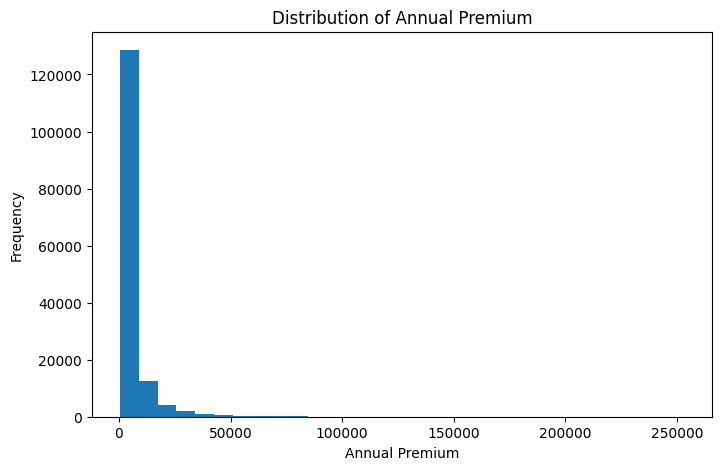

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_bike["annual_premium"], bins=30)
plt.title("Distribution of Annual Premium")
plt.xlabel("Annual Premium")
plt.ylabel("Frequency")
plt.show()

#Insured Declared Value (IDV) vs Annual Premium

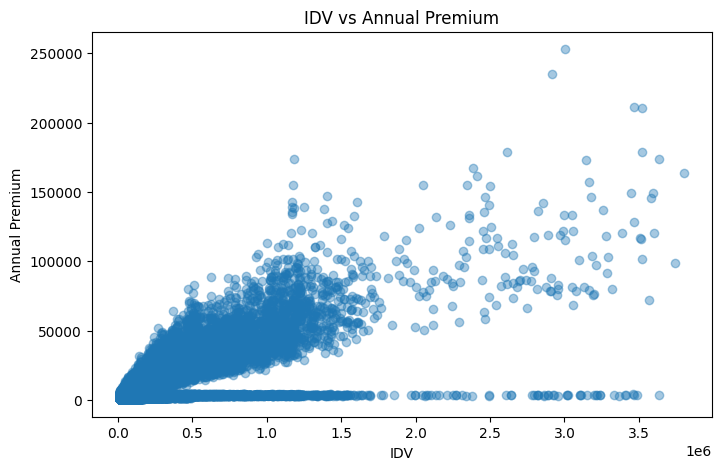

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df_bike["idv"], df_bike["annual_premium"], alpha=0.4)
plt.title("IDV vs Annual Premium")
plt.xlabel("IDV")
plt.ylabel("Annual Premium")
plt.show()

#Vehicle Age vs Annual Premium

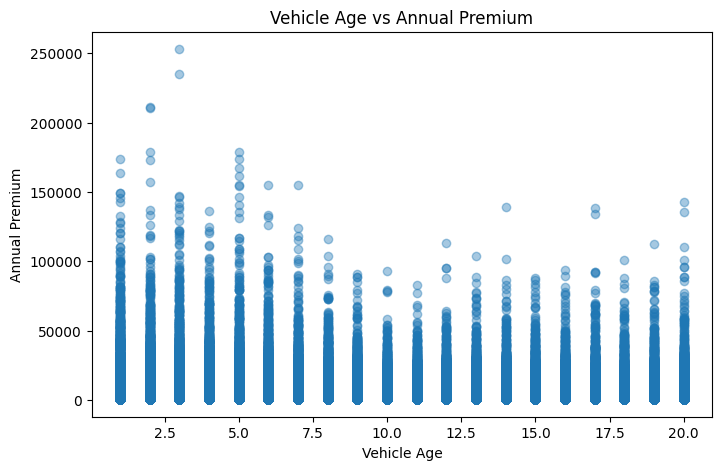

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df_bike["vehicle_age_years"], df_bike["annual_premium"], alpha=0.4)
plt.title("Vehicle Age vs Annual Premium")
plt.xlabel("Vehicle Age")
plt.ylabel("Annual Premium")
plt.show()

#Correlation Heatmap (numeric features)

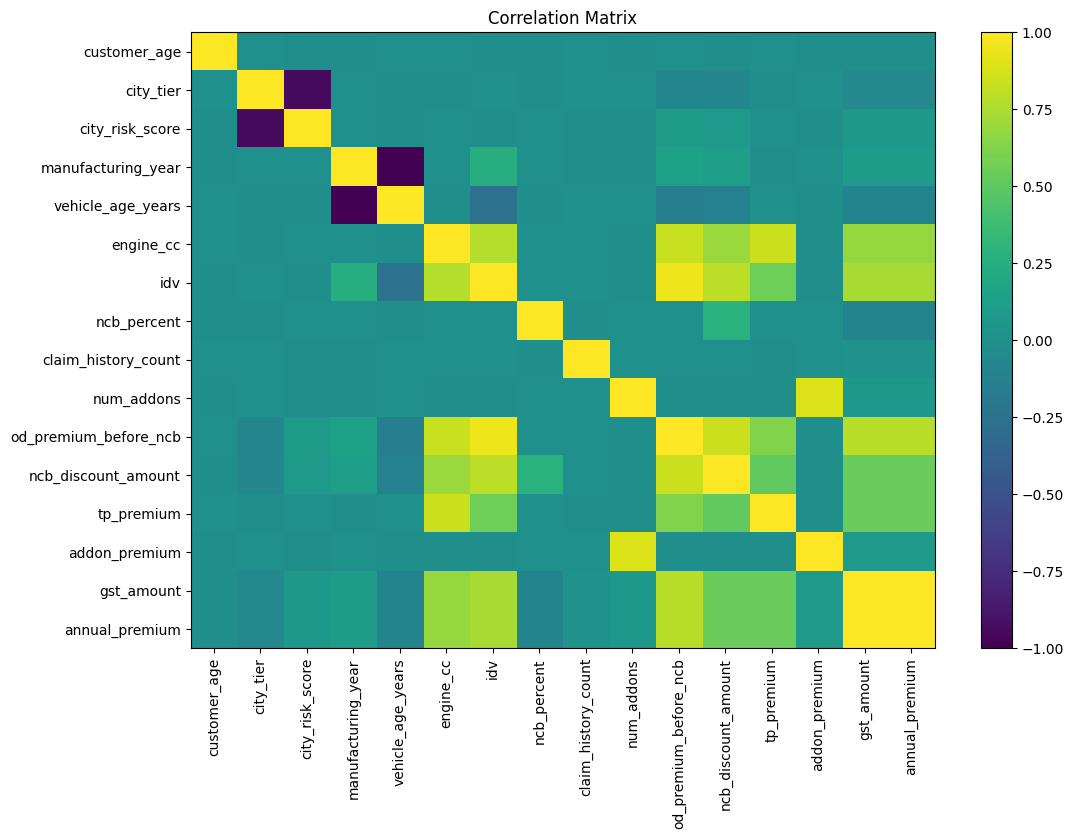

In [ ]:
import matplotlib.pyplot as plt

numeric_df = df_bike.select_dtypes(include="number")

plt.figure(figsize=(12,8))
plt.imshow(numeric_df.corr(), aspect="auto")
plt.colorbar()
plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)
plt.title("Correlation Matrix")
plt.show()

##Imports for Model Building

In [ ]:
#Data Preprocessing

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

#Pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#Model Building

from sklearn.ensemble import RandomForestRegressor

#Evaluation Metrics

from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score


##Splitting Feature Columns(X) and Target Column(Y)

In [ ]:
df_bike.columns

Index(['record_id', 'customer_age', 'city', 'state', 'city_tier',
       'city_risk_score', 'vehicle_make', 'vehicle_model', 'variant',
       'segment', 'fuel_type', 'colour', 'manufacturing_year',
       'vehicle_age_years', 'engine_cc', 'idv', 'ncb_percent',
       'claim_history_count', 'policy_type', 'usage_type', 'num_addons',
       'addons_list', 'od_premium_before_ncb', 'ncb_discount_amount',
       'tp_premium', 'addon_premium', 'gst_amount', 'annual_premium'],
      dtype='object')

In [ ]:
# Split Features and Target
X = df_bike.drop([
    'record_id',
    'annual_premium',
    'od_premium_before_ncb',
    'tp_premium',
    'addon_premium',
    'gst_amount',
    'ncb_discount_amount',
    'addons_list'
], axis=1)

Y = df_bike['annual_premium']


In [ ]:
X.head()

,customer_age,city,state,city_tier,city_risk_score,vehicle_make,vehicle_model,variant,segment,fuel_type,colour,manufacturing_year,vehicle_age_years,engine_cc,idv,ncb_percent,claim_history_count,policy_type,usage_type,num_addons
0,60,Rajahmundry,Andhra Pradesh,3,0.88,Royal Enfield,Bullet 500,STD,retro,Petrol,Sports Blue,2018,7,499,106815,0,0,Comprehensive,Personal,0
1,21,Indore,Madhya Pradesh,2,1.15,Yamaha,Fascino 125,ABS,scooter,Petrol,Yellow,2012,13,125,22704,45,0,Third Party,Personal,0
2,19,Patna,Bihar,2,1.20,Suzuki,Gixxer 150,Drum,sport,Petrol,Dual Tone,2011,14,155,36271,35,0,Third Party,Personal,3
3,20,Muzaffarpur,Bihar,3,0.88,Bounce,Infinity E1,ABS,ev_scooter,Electric,Matt Black,2011,14,0,21416,45,0,Comprehensive,Personal,0
4,19,Karnal,Haryana,3,0.90,Honda,CB Hornet 2.0,Limited Edition,sport,Petrol,Matt Black,2007,18,184,38836,45,0,Own Damage,Personal,0


In [ ]:
Y.head()

,annual_premium
0,8338
1,1035
2,1829
3,1536
4,1731


##Splitting Train and Test Data



In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((120000, 20), (30000, 20), (120000,), (30000,))

In [ ]:
df_bike.columns

Index(['record_id', 'customer_age', 'city', 'state', 'city_tier',
       'city_risk_score', 'vehicle_make', 'vehicle_model', 'variant',
       'segment', 'fuel_type', 'colour', 'manufacturing_year',
       'vehicle_age_years', 'engine_cc', 'idv', 'ncb_percent',
       'claim_history_count', 'policy_type', 'usage_type', 'num_addons',
       'addons_list', 'od_premium_before_ncb', 'ncb_discount_amount',
       'tp_premium', 'addon_premium', 'gst_amount', 'annual_premium'],
      dtype='object')

In [ ]:
Num_Col = X.select_dtypes(include=['int64','float64'])
Num_Col

,customer_age,city_tier,city_risk_score,manufacturing_year,vehicle_age_years,engine_cc,idv,ncb_percent,claim_history_count,num_addons
0,60,3,0.88,2018,7,499,106815,0,0,0
1,21,2,1.15,2012,13,125,22704,45,0,0
2,19,2,1.20,2011,14,155,36271,35,0,3
3,20,3,0.88,2011,14,0,21416,45,0,0
4,19,3,0.90,2007,18,184,38836,45,0,0
...,...,...,...,...,...,...,...,...,...,...
149995,45,1,1.30,2011,14,0,27491,35,0,1
149996,20,3,0.90,2011,14,184,40044,0,0,2
149997,65,2,1.10,2019,6,346,99123,0,0,1
149998,63,1,1.45,2023,2,159,104337,0,1,2


In [ ]:
Cat_Col = X.select_dtypes(include='object')
Cat_Col

,city,state,vehicle_make,vehicle_model,variant,segment,fuel_type,colour,policy_type,usage_type
0,Rajahmundry,Andhra Pradesh,Royal Enfield,Bullet 500,STD,retro,Petrol,Sports Blue,Comprehensive,Personal
1,Indore,Madhya Pradesh,Yamaha,Fascino 125,ABS,scooter,Petrol,Yellow,Third Party,Personal
2,Patna,Bihar,Suzuki,Gixxer 150,Drum,sport,Petrol,Dual Tone,Third Party,Personal
3,Muzaffarpur,Bihar,Bounce,Infinity E1,ABS,ev_scooter,Electric,Matt Black,Comprehensive,Personal
4,Karnal,Haryana,Honda,CB Hornet 2.0,Limited Edition,sport,Petrol,Matt Black,Own Damage,Personal
...,...,...,...,...,...,...,...,...,...,...
149995,Ahmedabad,Gujarat,Ola Electric,S1 X,Disc,ev_scooter,Electric,Gloss Black,Comprehensive,Personal
149996,Hisar,Haryana,Honda,CB Hornet 2.0,Limited Edition,sport,Petrol,Matte Grey,Comprehensive,Commercial
149997,Moradabad,Uttar Pradesh,Royal Enfield,Thunderbird 350X,Sport,cruiser,Petrol,Matte Grey,Third Party,Personal
149998,Bengaluru,Karnataka,TVS,Apache RTR 160 4V,STD,sport,Petrol,Racing Red,Comprehensive,Personal


#Preprocessing + Model Pipeline

In [ ]:
#Numerical Transformer

Num_trans = Pipeline(steps=[
    ('Imputing',SimpleImputer(strategy='median'))
])

#Categorical tranformer

Cat_trans = Pipeline(steps=[
    ('Imputing',SimpleImputer(strategy='most_frequent')),
    ('Encoding',OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1))
])

In [ ]:
#Column Transformer

Pre_Process_Step = ColumnTransformer(transformers=[
    ('Numerical_Transformer',Num_trans,Num_Col.columns),
    ('Categorical_Transformer',Cat_trans,Cat_Col.columns),
])

Pre_Process_Step

ColumnTransformer(transformers=[('Numerical_Transformer',
                                 Pipeline(steps=[('Imputing',
                                                  SimpleImputer(strategy='median'))]),
                                 Index(['customer_age', 'city_tier', 'city_risk_score', 'manufacturing_year',
       'vehicle_age_years', 'engine_cc', 'idv', 'ncb_percent',
       'claim_history_count', 'num_addons'],
      dtype='object')),
                                ('Categorical_Transformer',
                                 Pipeline(steps=[('Imputing',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('Encoding',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 Index(['city', 'state', 'vehicle_make', 'vehicle_model', 'variant', 'segment',
       'fuel_type', 'colour', 'policy_type', 'usage_type'],
      dtype='object'))])

##Model Training

#Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('Preprocessing', Pre_Process_Step),
    ('Model', RandomForestRegressor(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
))
])

rf_pipeline

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('Numerical_Transformer',
                                                  Pipeline(steps=[('Imputing',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['customer_age', 'city_tier', 'city_risk_score', 'manufacturing_year',
       'vehicle_age_years', 'engine_cc', 'idv', 'ncb_percent',
       'claim_history_count', 'num_addons'],
      dtype='object')),
                                                 ('Categorical_Tran...
                                                  Pipeline(steps=[('Imputing',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoding',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  Index(['city', 'state', 'vehicle_make', 'vehicle_model', 'variant', 'segment',
       'fuel_type', 'colour', 'policy_type', 'usage_type'],
      dtype='object'))])),
                ('Model',
                 RandomForestRegressor(n_estimators=30, n_jobs=-1,
                                       random_state=42))])

In [ ]:
Cat_Col.nunique().sort_values(ascending=False)

,0
vehicle_model,138
city,117
state,32
variant,16
segment,16
vehicle_make,13
colour,12
policy_type,3
usage_type,3
fuel_type,2


In [ ]:
# Train

rf_pipeline.fit(X_train, Y_train)

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('Numerical_Transformer',
                                                  Pipeline(steps=[('Imputing',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['customer_age', 'city_tier', 'city_risk_score', 'manufacturing_year',
       'vehicle_age_years', 'engine_cc', 'idv', 'ncb_percent',
       'claim_history_count', 'num_addons'],
      dtype='object')),
                                                 ('Categorical_Tran...
                                                  Pipeline(steps=[('Imputing',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoding',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  Index(['city', 'state', 'vehicle_make', 'vehicle_model', 'variant', 'segment',
       'fuel_type', 'colour', 'policy_type', 'usage_type'],
      dtype='object'))])),
                ('Model',
                 RandomForestRegressor(n_estimators=30, n_jobs=-1,
                                       random_state=42))])

In [ ]:
# Predict
Y_train_pred = rf_pipeline.predict(X_train)
Y_test_pred = rf_pipeline.predict(X_test)


##Model Evaluation

In [61]:
#Model Evaluation

#MAE for Train and Test data

MAE_train = mean_absolute_error(Y_train,Y_train_pred)
MAE_test=mean_absolute_error(Y_test,Y_test_pred)
print('Train MAE',MAE_train)
print('Test MAE',MAE_test)
print('\n')

#MSE for train and test data

MSE_train = mean_squared_error(Y_train,Y_train_pred)
MSE_test = mean_squared_error(Y_test,Y_test_pred)
#print('Train MSE',MSE_train)
#print('Test MSE',MSE_test)
#print('\n')

#RMSE for train and test data

RMSE_train = np.sqrt(MSE_train)
RMSE_test = np.sqrt(MSE_test)
print('Train RMSE',RMSE_train)
print('Test RMSE',RMSE_test)
print('\n')

#R2 Score

R2_train = r2_score(Y_train,Y_train_pred)
R2_test = r2_score(Y_test,Y_test_pred)
print('Train R2 Score',R2_train)
print('Test R2 Score',R2_test)


Train MAE 190.15200527777776
Test MAE 491.4852411111111


Train RMSE 506.81548305329653
Test RMSE 1215.1331071363243


Train R2 Score 0.9966758902153334
Test R2 Score 0.9796562585397804


##Saving the Model



In [62]:
import pickle

with open('bike_quote_pipeline.pkl', 'wb') as file:
    pickle.dump(rf_pipeline, file)

In [63]:
#Testing the pipeline

sample = pd.DataFrame({
    'customer_age':[30],
    'city':['Chennai'],
    'state':['Tamil Nadu'],
    'city_tier':[1],
    'city_risk_score':[0.85],
    'vehicle_make':['Honda'],
    'vehicle_model':['Activa'],
    'variant':['Standard'],
    'segment':['Scooter'],
    'fuel_type':['Petrol'],
    'colour':['Black'],
    'manufacturing_year':[2023],
    'vehicle_age_years':[2],
    'engine_cc':[110],
    'idv':[75000],
    'ncb_percent':[20],
    'claim_history_count':[0],
    'policy_type':['Comprehensive'],
    'usage_type':['Personal'],
    'num_addons':[1]
})

prediction = rf_pipeline.predict(sample)
print(prediction)

[3619.56666667]
